# P300 EEG -> Adaptive-LIF SNN classifier (block-averaged)



In [1]:
import numpy as np
import torch
import torch.nn as nn
from pathlib import Path
from scipy.io import loadmat
from scipy.signal import butter, filtfilt
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import (
    balanced_accuracy_score, classification_report,
    confusion_matrix, roc_auc_score
)
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)


# CONFIG


DATA_ROOT = Path("../data")     # same as  original notebook — change only if needed
SUBJECT = "SBJ01"
SESSIONS = None                 # None = auto-discover and use ALL sessions for this subject

FS = 250
LOWCUT = 0.1
HIGHCUT = 20.0

N_OBJECTS = 8            # objects in the P300 speller matrix (adjust if different)
EPOCHS_PER_BLOCK = 80    # 10 runs x 8 objects, same as your original BLOCK_SIZE

N_HIDDEN = 64
DROPOUT = 0.3
BATCH_SIZE = 32
N_EPOCHS = 100
LR = 3e-3
WEIGHT_DECAY = 1e-4
PATIENCE = 20
DOWNSAMPLE_FACTOR = 2    # 350 -> 175 timesteps: shortens BPTT and roughly halves training time
LOGIT_SCALE_INIT = 10.0

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


### 1. Data loading — ALL blocks, ALL sessions for the subject

Loads every session on disk for the subject (not just one block). Also keeps `events` (which object was flashed on each epoch) and a block-group id per epoch — both needed for the block-averaging step below.

In [2]:
def discover_sessions(subject_dir):
    return sorted(p for p in subject_dir.glob("S*") if (p / "Train").exists())


def load_session_train(session_dir):
    train_dir = session_dir / "Train"

    mat = loadmat(train_dir / "trainData.mat")
    data_vars = {k: v for k, v in mat.items() if not k.startswith("__")}
    eeg = list(data_vars.values())[0]                      # (channels, samples, epochs)
    X = np.transpose(eeg, (2, 0, 1)).astype(np.float32)     # (epochs, channels, samples)

    targets = np.loadtxt(train_dir / "trainTargets.txt", dtype=int).flatten()
    events = np.loadtxt(train_dir / "trainEvents.txt", dtype=int).flatten()

    block_ids = np.arange(len(targets)) // EPOCHS_PER_BLOCK
    return X, targets, events, block_ids


def load_subject_epochs(data_root, subject, sessions=None):
    subject_dir = data_root / subject
    session_dirs = (
        discover_sessions(subject_dir) if sessions is None
        else [subject_dir / s for s in sessions]
    )

    all_X, all_y, all_events, all_groups = [], [], [], []
    for session_dir in session_dirs:
        X, y, events, block_ids = load_session_train(session_dir)
        groups = [f"{session_dir.name}_B{b}" for b in block_ids]
        all_X.append(X)
        all_y.append(y)
        all_events.append(events)
        all_groups.extend(groups)
        print(f"  {session_dir.name}: {X.shape[0]} epochs "
              f"({int((y == 1).sum())} target / {int((y == 0).sum())} non-target)")

    X = np.concatenate(all_X, axis=0)
    y = np.concatenate(all_y, axis=0)
    events = np.concatenate(all_events, axis=0)
    groups = np.array(all_groups)
    return X, y, events, groups


print(f"Loading all sessions for {SUBJECT} ...")
X_raw, y_all, events_all, groups_all = load_subject_epochs(DATA_ROOT, SUBJECT, SESSIONS)
print(f"\nTotal epochs: {X_raw.shape[0]}  "
      f"(target={int((y_all == 1).sum())}, non-target={int((y_all == 0).sum())})")

Loading all sessions for SBJ01 ...
  S01: 1600 epochs (200 target / 1400 non-target)
  S02: 1600 epochs (200 target / 1400 non-target)
  S03: 1600 epochs (200 target / 1400 non-target)
  S04: 1600 epochs (200 target / 1400 non-target)
  S05: 1600 epochs (200 target / 1400 non-target)
  S06: 1600 epochs (200 target / 1400 non-target)
  S07: 1600 epochs (200 target / 1400 non-target)

Total epochs: 11200  (target=1400, non-target=9800)


### 2. Preprocessing

Same band-pass filter, baseline correction (-200 to 0 ms), and per-channel z-score normalization as your original Phase 1.

In [3]:
def preprocess_eeg(X, fs=250, lowcut=0.1, highcut=20.0, order=4):
    nyq = fs / 2
    b, a = butter(order, [lowcut / nyq, highcut / nyq], btype="band")
    X_filt = filtfilt(b, a, X, axis=-1)

    baseline_samples = int(0.2 * fs)  # epoch starts at -200 ms
    baseline_mean = X_filt[:, :, :baseline_samples].mean(axis=2, keepdims=True)
    X_bc = X_filt - baseline_mean

    ch_mean = X_bc.mean(axis=2, keepdims=True)
    ch_std = X_bc.std(axis=2, keepdims=True)
    X_norm = (X_bc - ch_mean) / (ch_std + 1e-8)
    return X_norm.astype(np.float32)


print("Preprocessing (bandpass + baseline correction + z-score)...")
X_prep = preprocess_eeg(X_raw, FS, LOWCUT, HIGHCUT)
print("Preprocessed shape:", X_prep.shape)

Preprocessing (bandpass + baseline correction + z-score)...
Preprocessed shape: (11200, 8, 350)


In [4]:
X_prep

array([[[ 0.9828572 ,  0.80434054,  0.6188117 , ..., -0.06945639,
         -0.1151591 , -0.17000216],
        [ 0.91726434,  0.52241486,  0.16089903, ...,  0.16288027,
          0.15749861,  0.1265184 ],
        [ 1.0429425 ,  0.5815481 ,  0.16093495, ...,  0.05829445,
          0.03592201, -0.02800204],
        ...,
        [ 0.83114904,  0.62818366,  0.43826473, ..., -0.11606465,
         -0.13799484, -0.17142577],
        [ 0.7568712 ,  0.37178254,  0.03228284, ...,  0.05765662,
          0.02961772, -0.01834695],
        [ 0.6372831 ,  0.29059717, -0.01525554, ...,  0.13816267,
          0.10667614,  0.06388666]],

       [[-1.5891676 , -1.2381597 , -0.8993428 , ..., -1.2056328 ,
         -0.89908737, -0.53930616],
        [-1.3585681 , -0.9731587 , -0.6039601 , ..., -1.3325131 ,
         -1.094039  , -0.8176039 ],
        [-1.2229224 , -0.8346209 , -0.46374607, ..., -0.98310465,
         -0.779371  , -0.54469156],
        ...,
        [-1.172652  , -0.86728084, -0.58049583, ..., -

### 3. Signal diagnostic — is there separable signal, and does averaging help?

Two cheap checks (seconds, not hours) before spending time training the SNN:
1. A trivial linear baseline (LDA / logistic regression on mean P300-window amplitude, cross-validated) on single trials — this is what first revealed the SNN was underperforming a two-line linear model on the same data.
2. The same check after collapsing repeated flashes of the same object within a block into one averaged epoch.

If both numbers come back near 0.5, the problem is upstream of any model (channels, timing, artifacts) and no amount of SNN tuning will fix it. If single-trial is clearly above 0.5 but the SNN still lands near 0.5 later in this notebook, that's a pipeline gap, not a data gap — worth revisiting the encoding step.

In [5]:
t_axis = np.arange(X_prep.shape[2]) / FS - 0.2   # epoch starts at -200 ms
p300_mask = (t_axis >= 0.25) & (t_axis <= 0.6)

# ---- 1. Single-trial linear baseline ----
feat_single = X_prep[:, :, p300_mask].mean(axis=2)   # (epochs, channels)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
auc_lda_single = cross_val_score(LinearDiscriminantAnalysis(), feat_single, y_all, cv=cv, scoring="roc_auc")
auc_lr_single = cross_val_score(LogisticRegression(class_weight="balanced", max_iter=1000), feat_single, y_all, cv=cv, scoring="roc_auc")

print("SINGLE-TRIAL linear baselines (cross-val ROC-AUC):")
print(f"  LDA:                 {auc_lda_single.mean():.3f} +/- {auc_lda_single.std():.3f}")
print(f"  Logistic Regression:  {auc_lr_single.mean():.3f} +/- {auc_lr_single.std():.3f}")
print("  ~0.5 => no separable signal in this window/preprocessing; >0.6 => signal is present")

SINGLE-TRIAL linear baselines (cross-val ROC-AUC):
  LDA:                 0.571 +/- 0.015
  Logistic Regression:  0.572 +/- 0.015
  ~0.5 => no separable signal in this window/preprocessing; >0.6 => signal is present


### 4. Block averaging

Collapses the repeated flashes of each object within a block into one averaged epoch — standard P300-speller SNR-boosting practice. This is the dataset the main path trains on below.

In [6]:
def build_block_averaged_dataset(X, y, events, groups):
    unique_groups = np.unique(groups)
    avg_X, avg_y, avg_group = [], [], []
    for g in unique_groups:
        block_mask = groups == g
        block_X = X[block_mask]
        block_y = y[block_mask]
        block_events = events[block_mask]
        for obj in np.unique(block_events):
            obj_mask = block_events == obj
            avg_X.append(block_X[obj_mask].mean(axis=0))
            avg_y.append(int(block_y[obj_mask][0]))   # constant within (block, object) group
            avg_group.append(g)
    return (np.array(avg_X, dtype=np.float32),
            np.array(avg_y, dtype=np.int64),
            np.array(avg_group))


X_avg, y_avg, groups_avg = build_block_averaged_dataset(X_prep, y_all, events_all, groups_all)
print(f"Block-averaged dataset: {X_avg.shape[0]} examples "
      f"({int(y_avg.sum())} target / {int((y_avg == 0).sum())} non-target), shape {X_avg.shape}")

# same diagnostic, on the averaged epochs, to confirm the SNR boost before training
feat_avg = X_avg[:, :, p300_mask].mean(axis=2)
cv2 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
auc_lda_avg = cross_val_score(LinearDiscriminantAnalysis(), feat_avg, y_avg, cv=cv2, scoring="roc_auc")
auc_lr_avg = cross_val_score(LogisticRegression(class_weight="balanced", max_iter=1000), feat_avg, y_avg, cv=cv2, scoring="roc_auc")
print("\nBLOCK-AVERAGED linear baselines (cross-val ROC-AUC):")
print(f"  LDA:                 {auc_lda_avg.mean():.3f} +/- {auc_lda_avg.std():.3f}")
print(f"  Logistic Regression:  {auc_lr_avg.mean():.3f} +/- {auc_lr_avg.std():.3f}")

Block-averaged dataset: 1120 examples (140 target / 980 non-target), shape (1120, 8, 350)

BLOCK-AVERAGED linear baselines (cross-val ROC-AUC):
  LDA:                 0.713 +/- 0.060
  Logistic Regression:  0.676 +/- 0.049


In [7]:
feat_avg

array([[-0.01214028, -0.06494951, -0.05878456, ..., -0.05195783,
        -0.15416402, -0.10700306],
       [-0.25329253, -0.3827428 , -0.2849809 , ..., -0.18542452,
        -0.25310254, -0.21141429],
       [-0.15019496, -0.15849032, -0.12524246, ..., -0.07098908,
        -0.0458279 , -0.01645504],
       ...,
       [-0.1487825 , -0.09642071, -0.11200258, ..., -0.2287935 ,
        -0.21057251, -0.26400712],
       [ 0.24968292,  0.11168292,  0.09502906, ...,  0.14305624,
         0.06716762,  0.07600812],
       [-0.04253001, -0.07577906, -0.09728551, ..., -0.02876213,
         0.01754592,  0.00329047]], dtype=float32)

In [8]:
X_avg

array([[[-0.02913485, -0.00824891,  0.00579379, ..., -0.16250107,
         -0.09707685, -0.02361843],
        [-0.42545477, -0.35445195, -0.28762287, ..., -0.3074438 ,
         -0.23074341, -0.13899949],
        [-0.59756577, -0.60328513, -0.60176325, ..., -0.20965576,
         -0.12503797, -0.02163892],
        ...,
        [-0.12537244, -0.00748204,  0.10460208, ..., -0.28705204,
         -0.18059587, -0.06350528],
        [-0.38199455, -0.31287208, -0.2452353 , ..., -0.23855722,
         -0.14044145, -0.02845024],
        [-0.2259512 , -0.10081013,  0.01961899, ..., -0.33931786,
         -0.22934751, -0.10723462]],

       [[-0.27435184, -0.24150245, -0.20859042, ..., -0.26444203,
         -0.28476295, -0.29183984],
        [-0.45332852, -0.43231788, -0.4111065 , ..., -0.11930501,
         -0.19976045, -0.27194855],
        [-0.6048087 , -0.52300775, -0.44319725, ..., -0.13522895,
         -0.26210886, -0.39153162],
        ...,
        [-0.3622473 , -0.26619858, -0.17476606, ..., -

### 5. SNN model and training loop

Same Adaptive-LIF dynamics as before (membrane leak `beta`, adaptation `rho`, surrogate-gradient spike function). Readout is the mean spike rate through a learnable scale, not a raw spike count. `train_snn(...)` bundles the split / train / evaluate loop into one function.

In [9]:
def rate_encode(X, seed=42):
    rng = np.random.default_rng(seed)
    X_min = X.min(axis=2, keepdims=True)
    X_max = X.max(axis=2, keepdims=True)
    X_norm = (X - X_min) / (X_max - X_min + 1e-8)
    spikes = (rng.random(X_norm.shape) < X_norm).astype(np.float32)
    return spikes


def downsample_time(spikes, factor=2):
    T = spikes.shape[2]
    T_trim = T - (T % factor)
    spikes = spikes[:, :, :T_trim]
    return spikes.reshape(spikes.shape[0], spikes.shape[1], -1, factor).max(axis=3)


class SpikeFunction(torch.autograd.Function):
    @staticmethod
    def forward(ctx, membrane, threshold):
        ctx.save_for_backward(membrane)
        ctx.threshold = threshold
        return (membrane >= threshold).float()

    @staticmethod
    def backward(ctx, grad_output):
        (membrane,) = ctx.saved_tensors
        threshold = ctx.threshold
        grad = 1.0 / (1.0 + torch.abs(membrane - threshold)) ** 2
        return grad_output * grad, None


spike_fn = SpikeFunction.apply


class AdaptiveLIFNet(nn.Module):
    """Hidden layer spikes (genuine SNN dynamics). Output layer is a
    continuous leaky-integrator, NOT a second spiking layer -- see the
    note above this cell for why."""
    def __init__(self, input_size=8, hidden_size=64, output_size=2,
                 beta=0.9, rho=0.95, adapt_strength=0.15,
                 dropout=0.3, threshold=1.0, logit_scale_init=10.0):
        super().__init__()
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.threshold = threshold
        self.beta = beta
        self.rho = rho
        self.adapt_strength = adapt_strength

        self.fc_in = nn.Linear(input_size, hidden_size)
        self.fc_out = nn.Linear(hidden_size, output_size)
        self.dropout = nn.Dropout(dropout)
        # scaled down from the raw init value since membrane potentials aren't
        # bounded to [0,1] the way a spike rate is
        self.logit_scale = nn.Parameter(torch.tensor(logit_scale_init * 0.1))

    def forward(self, x):
        batch, _, T = x.shape

        v = torch.zeros(batch, self.hidden_size, device=x.device)
        adapt = torch.zeros(batch, self.hidden_size, device=x.device)
        v_out = torch.zeros(batch, self.output_size, device=x.device)

        hidden_trace, membrane_trace = [], []

        for t in range(T):
            x_t = x[:, :, t]

            current = self.dropout(self.fc_in(x_t))
            v = self.beta * v + current - adapt
            s = spike_fn(v, self.threshold)
            v = v * (1.0 - s)
            adapt = self.rho * adapt + self.adapt_strength * s

            out_current = self.fc_out(s)
            v_out = self.beta * v_out + out_current   # continuous leaky-integrator, no reset/threshold here

            hidden_trace.append(s)
            membrane_trace.append(v_out)

        hidden_trace = torch.stack(hidden_trace, dim=1)
        membrane_trace = torch.stack(membrane_trace, dim=1)     # (batch, T, output_size)

        mean_potential = membrane_trace.mean(dim=1)
        logits = mean_potential * self.logit_scale

        return logits, hidden_trace, membrane_trace


def make_splits(y, groups=None, seed=42):
    """Block-grouped split when `groups` is given (keeps every example from the
    same block together, avoiding block-level leakage across train/val/test).
    Falls back to a plain stratified split if no groups are provided."""
    if groups is None:
        idx = np.arange(len(y))
        train_idx, temp_idx = train_test_split(idx, test_size=0.3, stratify=y, random_state=seed)
        val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, stratify=y[temp_idx], random_state=seed)
        return train_idx, val_idx, test_idx

    rng = np.random.default_rng(seed)
    unique_groups = np.unique(groups)
    rng.shuffle(unique_groups)

    n = len(unique_groups)
    n_train = int(0.7 * n)
    n_val = int(0.15 * n)
    train_groups = set(unique_groups[:n_train])
    val_groups = set(unique_groups[n_train:n_train + n_val])
    test_groups = set(unique_groups[n_train + n_val:])

    train_idx = np.where(np.isin(groups, list(train_groups)))[0]
    val_idx = np.where(np.isin(groups, list(val_groups)))[0]
    test_idx = np.where(np.isin(groups, list(test_groups)))[0]
    return train_idx, val_idx, test_idx


def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(history["train_loss"], label="Training")
    axes[0].plot(history["val_loss"], label="Validation")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
    axes[0].set_title(f"{title} — Loss"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(np.array(history["train_acc"]) * 100, label="Training")
    axes[1].plot(np.array(history["val_acc"]) * 100, label="Validation")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)")
    axes[1].set_title(f"{title} — Accuracy"); axes[1].legend(); axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def train_snn(spike_data, y, label, groups=None,
              n_epochs=N_EPOCHS, lr=LR, batch_size=BATCH_SIZE,
              hidden=N_HIDDEN, dropout=DROPOUT, logit_scale_init=LOGIT_SCALE_INIT,
              weight_decay=WEIGHT_DECAY, patience=PATIENCE, seed=42):

    torch.manual_seed(seed)
    np.random.seed(seed)

    train_idx, val_idx, test_idx = make_splits(y, groups=groups, seed=seed)
    train_X = torch.tensor(spike_data[train_idx], dtype=torch.float32)
    train_y = torch.tensor(y[train_idx], dtype=torch.long)
    val_X = torch.tensor(spike_data[val_idx], dtype=torch.float32).to(device)
    val_y = torch.tensor(y[val_idx], dtype=torch.long).to(device)
    test_X = torch.tensor(spike_data[test_idx], dtype=torch.float32).to(device)
    test_y = torch.tensor(y[test_idx], dtype=torch.long).to(device)

    print(f"[{label}] Train: {len(train_idx)} (target={(y[train_idx]==1).sum()})  "
          f"Val: {len(val_idx)} (target={(y[val_idx]==1).sum()})  "
          f"Test: {len(test_idx)} (target={(y[test_idx]==1).sum()})")

    model = AdaptiveLIFNet(input_size=8, hidden_size=hidden, output_size=2,
                            dropout=dropout, logit_scale_init=logit_scale_init).to(device)

    n0 = int((train_y == 0).sum()); n1 = int((train_y == 1).sum()); tot = n0 + n1
    class_weights = torch.tensor([tot / (2 * n0), tot / (2 * n1)], dtype=torch.float32, device=device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=5)
    train_loader = DataLoader(TensorDataset(train_X, train_y), batch_size=batch_size, shuffle=True)

    best_val_bal_acc = -1.0
    best_state = None
    patience_counter = 0
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    print(f"\n[{label}] Training...")
    for epoch in range(n_epochs):
        model.train()
        running_loss, running_correct, running_n = 0.0, 0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits, _, _ = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            running_loss += loss.item() * xb.size(0)
            running_correct += (logits.argmax(1) == yb).sum().item()
            running_n += xb.size(0)

        train_loss = running_loss / running_n
        train_acc = running_correct / running_n

        model.eval()
        with torch.no_grad():
            val_logits, _, _ = model(val_X)
            val_loss = criterion(val_logits, val_y).item()
            val_pred = val_logits.argmax(1)
            val_bal_acc = balanced_accuracy_score(val_y.cpu().numpy(), val_pred.cpu().numpy())
            val_acc = (val_pred == val_y).float().mean().item()

        scheduler.step(val_bal_acc)
        history["train_loss"].append(train_loss); history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc); history["val_acc"].append(val_acc)

        if val_bal_acc > best_val_bal_acc:
            best_val_bal_acc = val_bal_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        if epoch == 0 or (epoch + 1) % 5 == 0:
            print(f"  Epoch {epoch+1:3d}/{n_epochs} | "
                  f"Train Loss: {train_loss:.4f} Acc: {train_acc*100:.1f}% | "
                  f"Val Loss: {val_loss:.4f} Acc: {val_acc*100:.1f}% BalAcc: {val_bal_acc*100:.1f}%")

        if patience_counter >= patience:
            print(f"  Early stopping at epoch {epoch+1} (best val bal-acc: {best_val_bal_acc*100:.1f}%)")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    model.eval()
    with torch.no_grad():
        test_logits, test_hidden, test_membrane = model(test_X)
        test_probs = torch.softmax(test_logits, dim=1)[:, 1]
        test_pred = test_logits.argmax(1)

    true = test_y.cpu().numpy(); pred = test_pred.cpu().numpy(); probs = test_probs.cpu().numpy()

    print(f"\n[{label}] FINAL TEST RESULTS")
    print(classification_report(true, pred, target_names=["Non-target", "Target"], zero_division=0))
    print("Balanced accuracy:", balanced_accuracy_score(true, pred))
    try:
        test_auc = roc_auc_score(true, probs)
        print("ROC-AUC:", test_auc)
    except ValueError as e:
        test_auc = float("nan")
        print("ROC-AUC: n/a (", e, ")")
    print("Confusion matrix:")
    print(confusion_matrix(true, pred))

    return {
        "model": model, "history": history,
        "test_true": true, "test_pred": pred, "test_probs": probs,
        "test_hidden_trace": test_hidden.cpu().numpy(),
        "test_membrane_trace": test_membrane.cpu().numpy(),
        "balanced_accuracy": balanced_accuracy_score(true, pred),
        "roc_auc": test_auc,
    }

## Train and evaluate

Trains and evaluates the SNN on the block-averaged (high-SNR) dataset built above, using the block-grouped split.

In [10]:
spike_avg = rate_encode(X_avg, seed=42)
spike_avg = downsample_time(spike_avg, factor=DOWNSAMPLE_FACTOR)
print("Block-averaged spike train shape:", spike_avg.shape)

results_avg = train_snn(spike_avg, y_avg, label="block-averaged", groups=groups_avg)

Block-averaged spike train shape: (1120, 8, 175)
[block-averaged] Train: 784 (target=98)  Val: 168 (target=21)  Test: 168 (target=21)

[block-averaged] Training...
  Epoch   1/100 | Train Loss: 0.7090 Acc: 76.7% | Val Loss: 0.7392 Acc: 12.5% BalAcc: 50.0%
  Epoch   5/100 | Train Loss: 0.7043 Acc: 28.6% | Val Loss: 0.7176 Acc: 87.5% BalAcc: 50.0%
  Epoch  10/100 | Train Loss: 0.6935 Acc: 67.0% | Val Loss: 0.6909 Acc: 86.3% BalAcc: 49.3%
  Epoch  15/100 | Train Loss: 0.6906 Acc: 82.0% | Val Loss: 0.6907 Acc: 75.0% BalAcc: 55.1%
  Epoch  20/100 | Train Loss: 0.6910 Acc: 66.6% | Val Loss: 0.6905 Acc: 70.2% BalAcc: 56.5%
  Epoch  25/100 | Train Loss: 0.6913 Acc: 64.5% | Val Loss: 0.6927 Acc: 82.7% BalAcc: 49.3%
  Epoch  30/100 | Train Loss: 0.6905 Acc: 64.2% | Val Loss: 0.6919 Acc: 77.4% BalAcc: 54.4%
  Epoch  35/100 | Train Loss: 0.6896 Acc: 75.4% | Val Loss: 0.6923 Acc: 81.0% BalAcc: 56.5%
  Epoch  40/100 | Train Loss: 0.6888 Acc: 78.2% | Val Loss: 0.6924 Acc: 83.3% BalAcc: 53.7%
  Early 

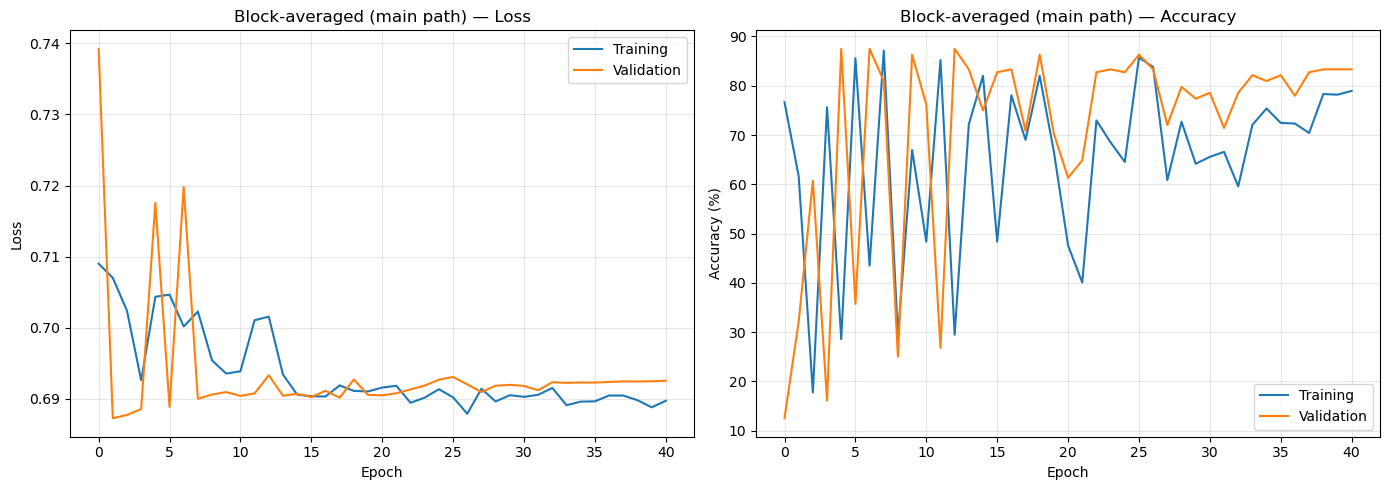

In [11]:
plot_history(results_avg["history"], title="Block-averaged (main path)")

### Save trajectories for the DDM stage

From the block-averaged model's held-out test set. Since each example here is already an averaged evidence signal across repeated flashes, this trajectory captures the SNN's within-epoch temporal dynamics on top of the across-repeat averaging.

In [12]:
print("Hidden spike trajectory:    ", results_avg["test_hidden_trace"].shape)
print("Output membrane trajectory: ", results_avg["test_membrane_trace"].shape)
print("\nNext stage: output membrane trajectory -> evidence trajectory -> DDM (v, a, t0)")


Hidden spike trajectory:     (168, 175, 64)
Output membrane trajectory:  (168, 175, 2)

Next stage: output membrane trajectory -> evidence trajectory -> DDM (v, a, t0)


### 6. Class-ratio experiment — resample to 1:2 (target : non-target)

The block-averaged dataset above is heavily imbalanced (140 target / 980 non-target, ~1:7). `class_weight` in the loss only re-weights the gradient — it doesn't change how many minority examples the model actually sees during training. Undersampling the majority (non-target) class down to a 1:2 ratio gives the model a training set where the classes are much closer in *count*, on top of the existing class-weighted loss.

This does **not** change the model, architecture, or hyperparameters — same `AdaptiveLIFNet`, same `train_snn()` call — only the class balance of the input data, so it's a clean apples-to-apples comparison against the ~1:7 run above.

In [13]:
def resample_class_ratio(X, y, groups, minority_label=1, ratio=2, seed=42):
    """Undersample the majority class so majority:minority == ratio:1.
    Keeps every minority-class example; randomly drops down the majority class."""
    rng = np.random.default_rng(seed)
    minority_idx = np.where(y == minority_label)[0]
    majority_idx = np.where(y != minority_label)[0]

    n_majority_keep = min(len(majority_idx), ratio * len(minority_idx))
    majority_keep = rng.choice(majority_idx, size=n_majority_keep, replace=False)

    keep_idx = np.concatenate([minority_idx, majority_keep])
    rng.shuffle(keep_idx)
    return X[keep_idx], y[keep_idx], groups[keep_idx]


X_avg_12, y_avg_12, groups_avg_12 = resample_class_ratio(
    X_avg, y_avg, groups_avg, minority_label=1, ratio=2, seed=42
)
print(f"1:2 resampled dataset: {X_avg_12.shape[0]} examples "
      f"({int((y_avg_12 == 1).sum())} target / {int((y_avg_12 == 0).sum())} non-target)")

1:2 resampled dataset: 420 examples (140 target / 280 non-target)


In [14]:
spike_avg_12 = rate_encode(X_avg_12, seed=42)
spike_avg_12 = downsample_time(spike_avg_12, factor=DOWNSAMPLE_FACTOR)
print("1:2 spike train shape:", spike_avg_12.shape)

results_avg_12 = train_snn(spike_avg_12, y_avg_12, label="block-averaged 1:2", groups=groups_avg_12)

1:2 spike train shape: (420, 8, 175)
[block-averaged 1:2] Train: 289 (target=98)  Val: 63 (target=21)  Test: 68 (target=21)

[block-averaged 1:2] Training...
  Epoch   1/100 | Train Loss: 0.7867 Acc: 55.0% | Val Loss: 0.7281 Acc: 33.3% BalAcc: 50.0%
  Epoch   5/100 | Train Loss: 0.6959 Acc: 63.0% | Val Loss: 0.6917 Acc: 63.5% BalAcc: 47.6%
  Epoch  10/100 | Train Loss: 0.6948 Acc: 62.6% | Val Loss: 0.6933 Acc: 63.5% BalAcc: 47.6%
  Epoch  15/100 | Train Loss: 0.6963 Acc: 66.1% | Val Loss: 0.6945 Acc: 66.7% BalAcc: 50.0%
  Epoch  20/100 | Train Loss: 0.6924 Acc: 66.4% | Val Loss: 0.6937 Acc: 65.1% BalAcc: 48.8%
  Epoch  25/100 | Train Loss: 0.6927 Acc: 46.0% | Val Loss: 0.6936 Acc: 54.0% BalAcc: 51.2%
  Early stopping at epoch 29 (best val bal-acc: 59.5%)

[block-averaged 1:2] FINAL TEST RESULTS
              precision    recall  f1-score   support

  Non-target       0.68      0.77      0.72        47
      Target       0.27      0.19      0.22        21

    accuracy                  

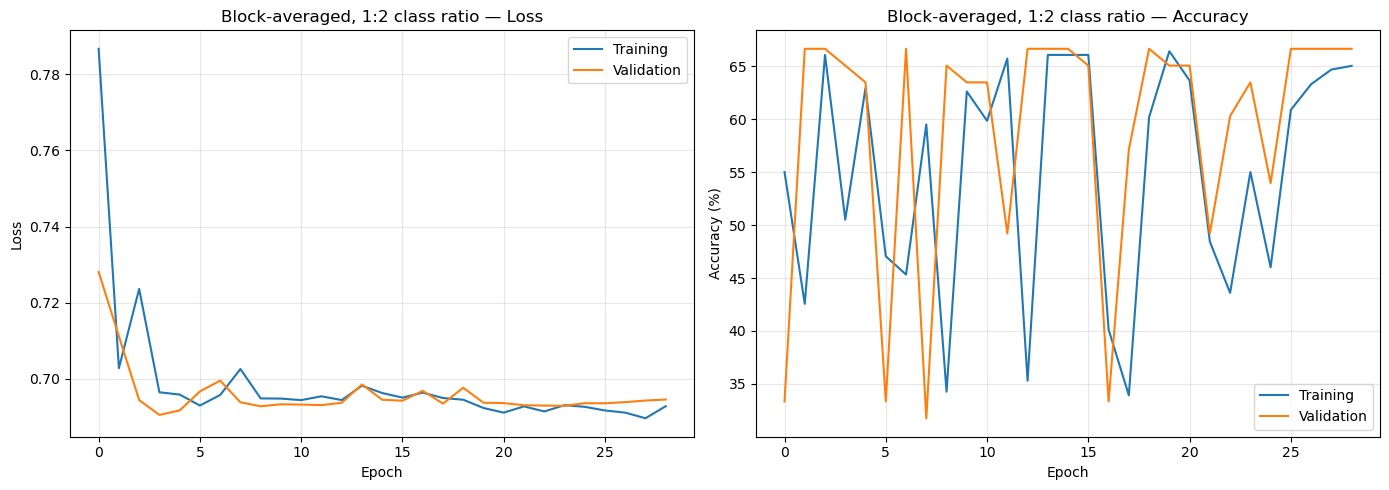

In [15]:
plot_history(results_avg_12["history"], title="Block-averaged, 1:2 class ratio")

In [16]:
print("Original  (~1:7) block-averaged:  BalAcc = {:.3f}  ROC-AUC = {:.3f}".format(
    results_avg["balanced_accuracy"], results_avg["roc_auc"]))
print("Resampled (1:2)  block-averaged:  BalAcc = {:.3f}  ROC-AUC = {:.3f}".format(
    results_avg_12["balanced_accuracy"], results_avg_12["roc_auc"]))

Original  (~1:7) block-averaged:  BalAcc = 0.463  ROC-AUC = 0.410
Resampled (1:2)  block-averaged:  BalAcc = 0.478  ROC-AUC = 0.427


### 7. (Optional) Small hyperparameter sweep on the 1:2 dataset

A quick grid over hidden size and learning rate, reusing `train_snn()` as-is. This will take longer to run (one full training per combination) — skip this cell if you just wanted the 1:2 comparison above.

In [17]:
def grid_search_snn(spike_data, y, groups, param_grid, label="grid-search", seed=42):
    """Run train_snn once per hyperparameter combo on the SAME split/seed,
    and rank combos by test balanced accuracy."""
    results = []
    for params in param_grid:
        print(f"\n--- Trying {params} ---")
        r = train_snn(spike_data, y, label=f"{label} {params}", groups=groups, seed=seed, **params)
        results.append((params, r))
    results.sort(key=lambda pr: pr[1]["balanced_accuracy"], reverse=True)
    print("\n=== Grid search summary (sorted by test balanced accuracy) ===")
    for params, r in results:
        print(f"{params} -> BalAcc={r['balanced_accuracy']:.3f}  ROC-AUC={r['roc_auc']:.3f}")
    return results


param_grid = [
    {"hidden": 32,  "lr": 3e-3},
    {"hidden": 64,  "lr": 3e-3},
    {"hidden": 128, "lr": 3e-3},
    {"hidden": 64,  "lr": 1e-3},
    {"hidden": 64,  "lr": 5e-3},
]

grid_results = grid_search_snn(spike_avg_12, y_avg_12, groups_avg_12, param_grid, label="1:2")
best_params, best_result = grid_results[0]
print("\nBest hyperparameters:", best_params)


--- Trying {'hidden': 32, 'lr': 0.003} ---
[1:2 {'hidden': 32, 'lr': 0.003}] Train: 289 (target=98)  Val: 63 (target=21)  Test: 68 (target=21)

[1:2 {'hidden': 32, 'lr': 0.003}] Training...
  Epoch   1/100 | Train Loss: 0.7080 Acc: 49.1% | Val Loss: 0.6952 Acc: 33.3% BalAcc: 50.0%
  Epoch   5/100 | Train Loss: 0.6955 Acc: 57.1% | Val Loss: 0.6947 Acc: 33.3% BalAcc: 50.0%
  Epoch  10/100 | Train Loss: 0.6937 Acc: 65.1% | Val Loss: 0.6937 Acc: 66.7% BalAcc: 50.0%
  Epoch  15/100 | Train Loss: 0.6957 Acc: 66.1% | Val Loss: 0.6945 Acc: 66.7% BalAcc: 50.0%
  Epoch  20/100 | Train Loss: 0.6933 Acc: 58.1% | Val Loss: 0.6939 Acc: 47.6% BalAcc: 51.2%
  Early stopping at epoch 22 (best val bal-acc: 51.2%)

[1:2 {'hidden': 32, 'lr': 0.003}] FINAL TEST RESULTS
              precision    recall  f1-score   support

  Non-target       0.67      0.81      0.73        47
      Target       0.18      0.10      0.12        21

    accuracy                           0.59        68
   macro avg       0.4

In [18]:
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.feature_selection import SelectKBest, mutual_info_classif, f_classif, RFE, SelectFromModel
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import pandas as pd
import warnings

# Same grouping used by train_snn(), extended to k-fold + stratified.
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

results_table = []  # (method, roc_auc_mean, roc_auc_std)

# ---- corrected (leakage-safe) raw mean-amplitude baseline, for a fair comparison ----
auc_lda_raw_fixed = cross_val_score(
    LinearDiscriminantAnalysis(), feat_avg, y_avg, groups=groups_avg, cv=cv, scoring="roc_auc"
)
auc_lr_raw_fixed = cross_val_score(
    LogisticRegression(class_weight="balanced", max_iter=1000), feat_avg, y_avg, groups=groups_avg, cv=cv, scoring="roc_auc"
)
print("Raw mean-amplitude baseline, CORRECTED (StratifiedGroupKFold):")
print(f"  LDA:     {auc_lda_raw_fixed.mean():.3f} +/- {auc_lda_raw_fixed.std():.3f}   (was {auc_lda_avg.mean():.3f} with the leaky split)")
print(f"  LogReg:  {auc_lr_raw_fixed.mean():.3f} +/- {auc_lr_raw_fixed.std():.3f}   (was {auc_lr_avg.mean():.3f} with the leaky split)")

results_table.append(("Raw mean-amplitude, LDA (corrected CV)", auc_lda_raw_fixed.mean(), auc_lda_raw_fixed.std()))
results_table.append(("Raw mean-amplitude, LogReg (corrected CV)", auc_lr_raw_fixed.mean(), auc_lr_raw_fixed.std()))

Raw mean-amplitude baseline, CORRECTED (StratifiedGroupKFold):
  LDA:     0.698 +/- 0.033   (was 0.713 with the leaky split)
  LogReg:  0.675 +/- 0.028   (was 0.676 with the leaky split)


### Wavelet feature extraction

The P300 is a transient, time-localized waveform — a single window-mean amplitude (what the baseline above uses) throws away its shape, and the spiking encoding throws away its amplitude. A discrete wavelet transform (DWT) decomposes each channel's time course into time-frequency bands, which is a much more natural match for a transient waveform than either of those. Per channel, `wavedec` gives one approximation band + `level` detail bands; each band is summarized with 3 cheap statistics (mean |coefficient|, RMS/energy, std) instead of keeping every raw coefficient, to keep the feature count sane relative to how few examples this dataset has.

In [19]:
import pywt

def extract_wavelet_features(X, wavelet="db4", level=4):
    """Per-channel DWT, summarized per band. X: (epochs, channels, time) -> (epochs, features)."""
    n_epochs, n_channels, n_time = X.shape
    n_bands = level + 1
    feats = np.zeros((n_epochs, n_channels * n_bands * 3), dtype=np.float32)
    for i in range(n_epochs):
        col = 0
        for ch in range(n_channels):
            coeffs = pywt.wavedec(X[i, ch], wavelet=wavelet, level=level)
            for band in coeffs:
                feats[i, col] = np.mean(np.abs(band)); col += 1
                feats[i, col] = np.sqrt(np.mean(band ** 2)); col += 1
                feats[i, col] = np.std(band); col += 1
    return feats


feat_wave_avg = extract_wavelet_features(X_avg, wavelet="db4", level=4)
print("Wavelet feature matrix:", feat_wave_avg.shape)

auc_lda_wave = cross_val_score(LinearDiscriminantAnalysis(), feat_wave_avg, y_avg, groups=groups_avg, cv=cv, scoring="roc_auc")
auc_lr_wave = cross_val_score(LogisticRegression(class_weight="balanced", max_iter=2000), feat_wave_avg, y_avg, groups=groups_avg, cv=cv, scoring="roc_auc")
print("\nWavelet features, no selection (corrected CV):")
print(f"  LDA:     {auc_lda_wave.mean():.3f} +/- {auc_lda_wave.std():.3f}")
print(f"  LogReg:  {auc_lr_wave.mean():.3f} +/- {auc_lr_wave.std():.3f}")

results_table.append(("Wavelet (all features), LDA", auc_lda_wave.mean(), auc_lda_wave.std()))
results_table.append(("Wavelet (all features), LogReg", auc_lr_wave.mean(), auc_lr_wave.std()))

Wavelet feature matrix: (1120, 120)

Wavelet features, no selection (corrected CV):
  LDA:     0.548 +/- 0.049
  LogReg:  0.589 +/- 0.043


### Feature selection

With only 140 target examples total (~112 in a typical training fold), a 120-dimensional wavelet feature vector has real overfitting risk — feature selection is there to cut that down before a linear model sees it. Four different selection criteria, each wrapped in a `Pipeline` with the classifier so `cross_val_score` refits the selector on the **training fold only** each time (this is the part that's easy to get wrong: fitting a selector on the full dataset before cross-validating leaks test-fold labels into the feature choice):

- **ANOVA F-score** (`SelectKBest(f_classif)`) — fast univariate test, assumes roughly linear class separation per feature.
- **Mutual information** (`SelectKBest(mutual_info_classif)`) — univariate but captures non-linear relevance.
- **L1-penalized logistic regression** (`SelectFromModel`) — multivariate, sparse; features are chosen jointly, not one at a time.
- **RFE** — multivariate, greedy backward elimination with a logistic regression estimator.

In [20]:
warnings.filterwarnings("ignore", category=FutureWarning)

def make_pipe(selector):
    steps = [("scale", StandardScaler())]
    if selector is not None:
        steps.append(("select", selector))
    steps.append(("clf", LinearDiscriminantAnalysis()))
    return Pipeline(steps)


K = 20  # features to keep for the k-based selectors; adjust and re-run to sweep this

selectors = {
    "ANOVA F-score (k=20)":       SelectKBest(f_classif, k=K),
    "Mutual information (k=20)":  SelectKBest(mutual_info_classif, k=K),
    "L1-logreg (SelectFromModel)": SelectFromModel(LogisticRegression(penalty="l1", solver="liblinear", C=0.1, class_weight="balanced")),
    "RFE + LogReg (k=20)":         RFE(LogisticRegression(max_iter=2000, class_weight="balanced"), n_features_to_select=K),
}

for name, sel in selectors.items():
    pipe = make_pipe(sel)
    auc = cross_val_score(pipe, feat_wave_avg, y_avg, groups=groups_avg, cv=cv, scoring="roc_auc")
    print(f"{name:32s} {auc.mean():.3f} +/- {auc.std():.3f}")
    results_table.append((f"Wavelet + {name}", auc.mean(), auc.std()))

ANOVA F-score (k=20)             0.594 +/- 0.044
Mutual information (k=20)        0.540 +/- 0.066
L1-logreg (SelectFromModel)      0.538 +/- 0.050
RFE + LogReg (k=20)              0.560 +/- 0.016


### Lightweight 1D-CNN — learned features, as a comparison point

A CNN learns its own filters instead of using hand-designed wavelet bands, but with ~140 target examples it can also memorize noise far more easily than a 20-feature linear model can. This is deliberately small (2 conv layers, global average pooling, dropout + weight decay, no dense hidden layer) and evaluated with the same `StratifiedGroupKFold` protocol — a fresh model is trained per fold, since that's the correct way to cross-validate a neural net (fitting once and scoring on held-out folds without retraining would leak). **This cell needs `torch`, which isn't available in the sandbox that built this notebook — it hasn't been executed here.** It's written in the same style as your working `AdaptiveLIFNet` code, so it should run as-is in your environment.

In [21]:
class TinyCNN(nn.Module):
    def __init__(self, n_channels, dropout=0.4):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(n_channels, 8, kernel_size=9, padding=4), nn.BatchNorm1d(8), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(8, 16, kernel_size=9, padding=4), nn.BatchNorm1d(16), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(16, 2)

    def forward(self, x):
        z = self.features(x).squeeze(-1)
        return self.fc(self.drop(z))


def cv_evaluate_cnn(X, y, groups, cv, epochs=25, lr=1e-3, weight_decay=1e-3, seed=42):
    aucs = []
    for fold, (tr_idx, te_idx) in enumerate(cv.split(X, y, groups)):
        torch.manual_seed(seed + fold)
        Xtr = torch.tensor(X[tr_idx]); ytr = torch.tensor(y[tr_idx])
        Xte = torch.tensor(X[te_idx]); yte = y[te_idx]

        # standardize using TRAIN-fold stats only, then apply to the held-out fold
        mu = Xtr.mean(dim=(0, 2), keepdim=True)
        sd = Xtr.std(dim=(0, 2), keepdim=True) + 1e-8
        Xtr = (Xtr - mu) / sd
        Xte = (Xte - mu) / sd

        model = TinyCNN(X.shape[1]).to(device)
        classes, counts = np.unique(ytr.numpy(), return_counts=True)
        w = np.zeros(2, dtype=np.float32)
        w[classes] = counts.sum() / (len(classes) * counts)
        loss_fn = nn.CrossEntropyLoss(weight=torch.tensor(w, device=device))
        opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

        dl = DataLoader(TensorDataset(Xtr, ytr), batch_size=32, shuffle=True)

        model.train()
        for _ in range(epochs):
            for xb, yb in dl:
                xb, yb = xb.to(device), yb.to(device)
                opt.zero_grad()
                loss_fn(model(xb), yb).backward()
                opt.step()

        model.eval()
        with torch.no_grad():
            probs = torch.softmax(model(Xte.to(device)), dim=1)[:, 1].cpu().numpy()
        aucs.append(roc_auc_score(yte, probs))
    return np.array(aucs)


cnn_aucs = cv_evaluate_cnn(X_avg, y_avg, groups_avg, cv, epochs=25)
print(f"TinyCNN (corrected CV): {cnn_aucs.mean():.3f} +/- {cnn_aucs.std():.3f}")
results_table.append(("TinyCNN, learned features", cnn_aucs.mean(), cnn_aucs.std()))

TinyCNN (corrected CV): 0.662 +/- 0.039


### Side-by-side comparison

All rows above use the same leakage-safe, group-respecting CV protocol, so they're directly comparable to each other. The SNN numbers from earlier in the notebook are added for reference — note those came from a **single** grouped train/val/test split, not 5-fold CV, so treat that comparison as directional rather than exact.

In [ ]:
results_table.append(("SNN, rate-coded, ~1:7 split (single split, not CV)", results_avg["roc_auc"], float("nan")))
results_table.append(("SNN, rate-coded, 1:2 split (single split, not CV)", results_avg_12["roc_auc"], float("nan")))
results_table.append(("SNN, hidden=128 lr=0.003, 1:2 split (single split, not CV)", best_result["roc_auc"], float("nan")))

df = pd.DataFrame(results_table, columns=["method", "roc_auc_mean", "roc_auc_std"])
df = df.sort_values("roc_auc_mean", ascending=False).reset_index(drop=True)
df

,method,roc_auc_mean,roc_auc_std
0,"Raw mean-amplitude, LDA (corrected CV)",0.697886,0.032665
1,"Raw mean-amplitude, LogReg (corrected CV)",0.674818,0.027630
2,"TinyCNN, learned features",0.661516,0.038648
3,Wavelet + ANOVA F-score (k=20),0.594060,0.043509
4,"SNN, hidden=128 lr=0.003, 1:2 split (single sp...",0.592705,NaN
5,"Wavelet (all features), LogReg",0.589103,0.042737
6,Wavelet + RFE + LogReg (k=20),0.560022,0.015507
7,"Wavelet (all features), LDA",0.548433,0.048719
8,Wavelet + Mutual information (k=20),0.540160,0.065891
9,Wavelet + L1-logreg (SelectFromModel),0.538229,0.050158


: 